In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupKFold
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
#load các dataframe, đọc và thống kê số lượng

data_dir = '/Users/stella/Downloads/Data Training/data'

all_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.csv')]

df_list = []
for f in all_files:
    temp_df = pd.read_csv(f)
    match = re.search(r'sensors_data_(\d+)\.csv', f)
    user_id = int(match.group(1)) if match else 0 # Assign user 0 for 'pause_sign.csv'
    temp_df['user'] = user_id
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

print("--- Data Loaded and Combined Successfully ---")
print(f"Total rows: {len(df)}, Total columns: {len(df.columns)}")

--- Data Loaded and Combined Successfully ---
Total rows: 93000, Total columns: 11


In [7]:
import glob
import pandas as pd  

path = "/Users/stella/Downloads/Data Training/data/*.csv"
files = glob.glob(path)

df_list = [pd.read_csv(f) for f in files]  
df = pd.concat(df_list, ignore_index=True)

print(df.columns)
print(df.head())


Index(['flex1', 'flex2', 'flex3', 'flex4', 'flex5', 'x', 'y', 'z', 'face',
       'SIGN'],
      dtype='object')
   flex1  flex2  flex3  flex4   flex5       x      y      z   face    SIGN
0    1.0    2.0    2.0    1.0  1889.0  252.06 -64.44  76.50  0.004  Hẹn Hò
1    0.0    1.0    1.0    1.0  1889.0  254.31 -64.00  72.00  0.002  Hẹn Hò
2    1.0    1.0    0.0    1.0  1889.0  254.44 -63.19  65.19  0.003  Hẹn Hò
3    1.0    2.0    1.0    0.0  1888.0  252.81 -65.56  60.50  0.002  Hẹn Hò
4    2.0    2.0    0.0    1.0  1889.0  253.19 -67.56  60.69  0.002  Hẹn Hò


In [8]:
label_col = "SIGN"                 # label cuối cùng cho mỗi chuỗi
sensor_cols = ['flex1','flex2','flex3','flex4','flex5','x','y','z','face']   

print("Sensor features:", sensor_cols)
label_encoder = LabelEncoder()
df["sign_encoded"] = label_encoder.fit_transform(df[label_col])
num_classes = len(label_encoder.classes_)

print("\nClasses:", label_encoder.classes_)
print("Total classes:", num_classes)

scaler = StandardScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

print("\n--- Preprocessing Done ✔ ---")
print(f"Total features: {len(sensor_cols)} | Classes: {num_classes}")


Sensor features: ['flex1', 'flex2', 'flex3', 'flex4', 'flex5', 'x', 'y', 'z', 'face']

Classes: ['Hẹn Hò' 'Tôi' 'Xin Chào']
Total classes: 3

--- Preprocessing Done ✔ ---
Total features: 9 | Classes: 3


In [9]:
import numpy as np
from tensorflow.keras.utils import to_categorical

TIME_STEPS = 20   # vì bạn thu 20 frames cho mỗi sample

# reshape thành (samples, 20, 9 features)
X = df[sensor_cols].values.reshape(-1, TIME_STEPS, len(sensor_cols))

# label mỗi sample là nhãn đầu của 20 frame
y_int = df['sign_encoded'].values.reshape(-1, TIME_STEPS)[:, 0]
y = to_categorical(y_int, num_classes=num_classes)

print("X shape:", X.shape)  # expected -> (num_samples, 20, 9)
print("y shape:", y.shape)  # expected -> (num_samples, num_classes)
print("Samples:", X.shape[0])


X shape: (4650, 20, 9)
y shape: (4650, 3)
Samples: 4650


In [10]:
X = df[sensor_cols].values.reshape(-1,20,9)
y_int = df['sign_encoded'].values.reshape(-1,20)[:,0]
y = to_categorical(y_int, num_classes=num_classes)


In [11]:
from sklearn.model_selection import KFold   # đổi GroupKFold -> KFold vì single-user
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np

N_SPLITS = 5                                # 5-fold CV (tùy chỉnh)
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

print(f"--- Starting {N_SPLITS}-Fold Cross-Validation ---")

all_acc_scores = []
best_acc = 0
best_model = None

fold = 0
for train_idx, test_idx in kf.split(X):
    fold += 1
    print(f"\n--- FOLD {fold}/{N_SPLITS} ---")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # ----- Build Model (same as original) -----
    inputs = Input(shape=(TIME_STEPS, X_train.shape[2]))
    x = LSTM(64, return_sequences=True)(inputs)
    x = Dropout(0.5)(x)
    x = LSTM(64)(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # ----- Callbacks -----
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    checkpoint = ModelCheckpoint(f"model_fold_{fold}.h5", save_best_only=True, monitor='val_accuracy')

    # ----- Train -----
    model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping, checkpoint],
        verbose=1
    )

    # ----- Evaluate -----
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Fold {fold} Accuracy: {accuracy*100:.2f}%")
    all_acc_scores.append(accuracy)

    # Save best model across all folds
    if accuracy > best_acc:
        best_acc = accuracy
        best_model = model
        model.save("model_best.h5")
        print("🔥 New best model saved as model_best.h5")

# ---------------- Summary ----------------
print("\n--- Cross-Validation Summary ---")
print(f"Mean Accuracy: {np.mean(all_acc_scores)*100:.2f}%")
print(f"Std Dev: {np.std(all_acc_scores)*100:.2f}%")


--- Starting 5-Fold Cross-Validation ---

--- FOLD 1/5 ---


2025-12-07 16:31:26.281168: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-12-07 16:31:26.281382: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-07 16:31:26.281399: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-12-07 16:31:26.282013: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-07 16:31:26.282420: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/50


2025-12-07 16:31:27.848022: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-07 16:31:28.116673: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-07 16:31:28.565423: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-07 16:31:30.098404: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-07 16:31:30.638158: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


59/59 [==============================] - ETA: 0s - loss: 0.5722 - accuracy: 0.7594

...

 4/59 [=>............................] - ETA: 1s - loss: 1.0442 - accuracy: 0.4102  

2025-12-07 16:33:07.471302: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


59/59 [==============================] - ETA: 0s - loss: 0.5692 - accuracy: 0.7718

2025-12-07 16:33:08.775404: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-07 16:33:08.845990: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-07 16:33:08.888907: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


59/59 [==============================] - 5s 26ms/step - loss: 0.5692 - accuracy: 0.7718 - val_loss: 0.3848 - val_accuracy: 0.8688
Epoch 2/50
59/59 [==============================] - 1s 17ms/step - loss: 0.2471 - accuracy: 0.9164 - val_loss: 0.2050 - val_accuracy: 0.9258
Epoch 3/50
59/59 [==============================] - 1s 17ms/step - loss: 0.1436 - accuracy: 0.9551 - val_loss: 0.1349 - val_accuracy: 0.9570
Epoch 4/50
59/59 [==============================] - 1s 16ms/step - loss: 0.0967 - accuracy: 0.9694 - val_loss: 0.0999 - val_accuracy: 0.9581
Epoch 5/50
59/59 [==============================] - 1s 17ms/step - loss: 0.0736 - accuracy: 0.9782 - val_loss: 0.0940 - val_accuracy: 0.9656
Epoch 6/50
59/59 [==============================] - 1s 16ms/step - loss: 0.0560 - accuracy: 0.9820 - val_loss: 0.0672 - val_accuracy: 0.9763
Epoch 7/50
59/59 [==============================] - 1s 14ms/step - loss: 0.0484 - accuracy: 0.9844 - val_loss: 0.1218 - val_accuracy: 0.9667
Epoch 8/50
59/59 [======



--- Training Final Model on All Data for Detailed Analysis ---

--- Starting Final Training ---
Epoch 1/50


2025-12-07 16:33:22.320116: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-07 16:33:22.476458: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-07 16:33:22.556196: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-07 16:33:22.796217: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-07 16:33:22.933664: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


30/30 [==============================] - ETA: 0s - loss: 0.7369 - accuracy: 0.7035

2025-12-07 16:33:23.759541: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-07 16:33:23.816058: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-07 16:33:23.851237: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


30/30 [==============================] - 3s 31ms/step - loss: 0.7369 - accuracy: 0.7035 - val_loss: 0.7619 - val_accuracy: 0.7000
Epoch 2/50
30/30 [==============================] - 0s 16ms/step - loss: 0.2886 - accuracy: 0.8944 - val_loss: 0.6142 - val_accuracy: 0.8075
Epoch 3/50
30/30 [==============================] - 0s 16ms/step - loss: 0.1463 - accuracy: 0.9468 - val_loss: 0.5602 - val_accuracy: 0.8495
Epoch 4/50
30/30 [==============================] - 1s 18ms/step - loss: 0.0848 - accuracy: 0.9726 - val_loss: 0.6307 - val_accuracy: 0.7806
Epoch 5/50
30/30 [==============================] - 0s 16ms/step - loss: 0.0841 - accuracy: 0.9728 - val_loss: 0.3357 - val_accuracy: 0.8925
Epoch 6/50
30/30 [==============================] - 1s 18ms/step - loss: 0.0625 - accuracy: 0.9788 - val_loss: 0.3252 - val_accuracy: 0.9000
Epoch 7/50
30/30 [==============================] - 0s 17ms/step - loss: 0.0512 - accuracy: 0.9831 - val_loss: 0.3253 - val_accuracy: 0.8699
Epoch 8/50
30/30 [======

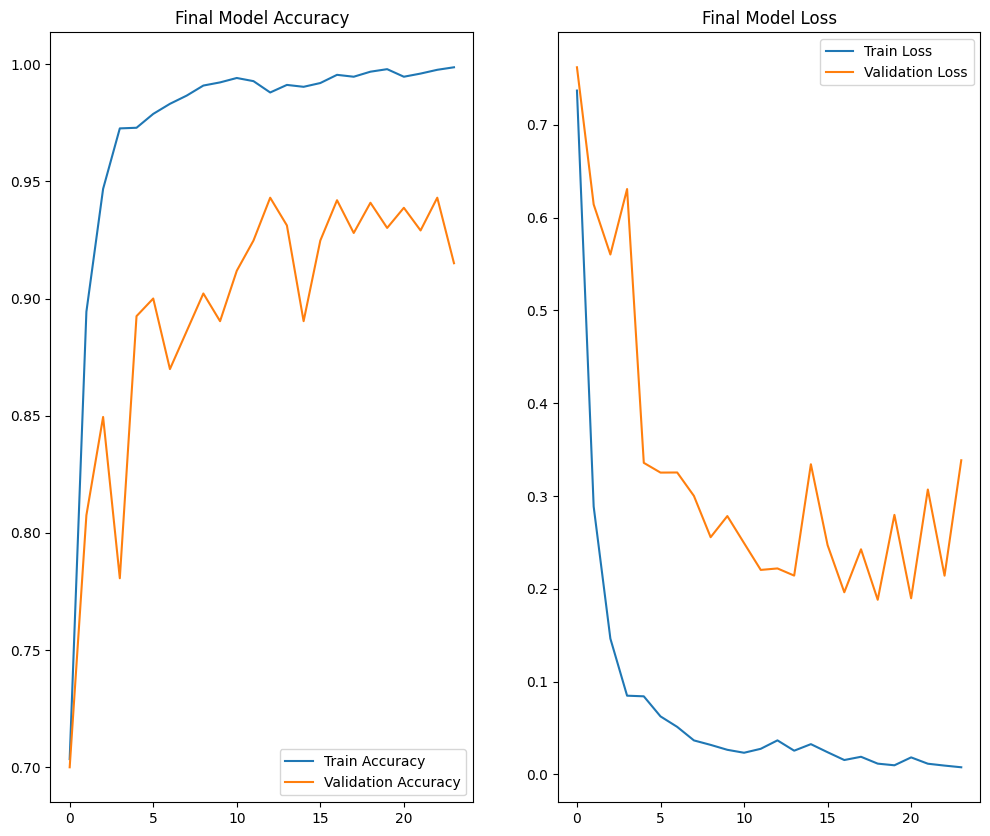



--- Final Model Performance Analysis (on all data) ---
 17/146 [==>...........................] - ETA: 0s 

2025-12-07 16:33:35.980112: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-07 16:33:36.028081: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-07 16:33:36.064342: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


146/146 [==============================] - 1s 5ms/step

Classification Report:
              precision    recall  f1-score   support

      Hẹn Hò       0.94      1.00      0.97      1350
         Tôi       1.00      1.00      1.00      2624
    Xin Chào       1.00      0.87      0.93       676

    accuracy                           0.98      4650
   macro avg       0.98      0.96      0.97      4650
weighted avg       0.98      0.98      0.98      4650



Confusion Matrix:


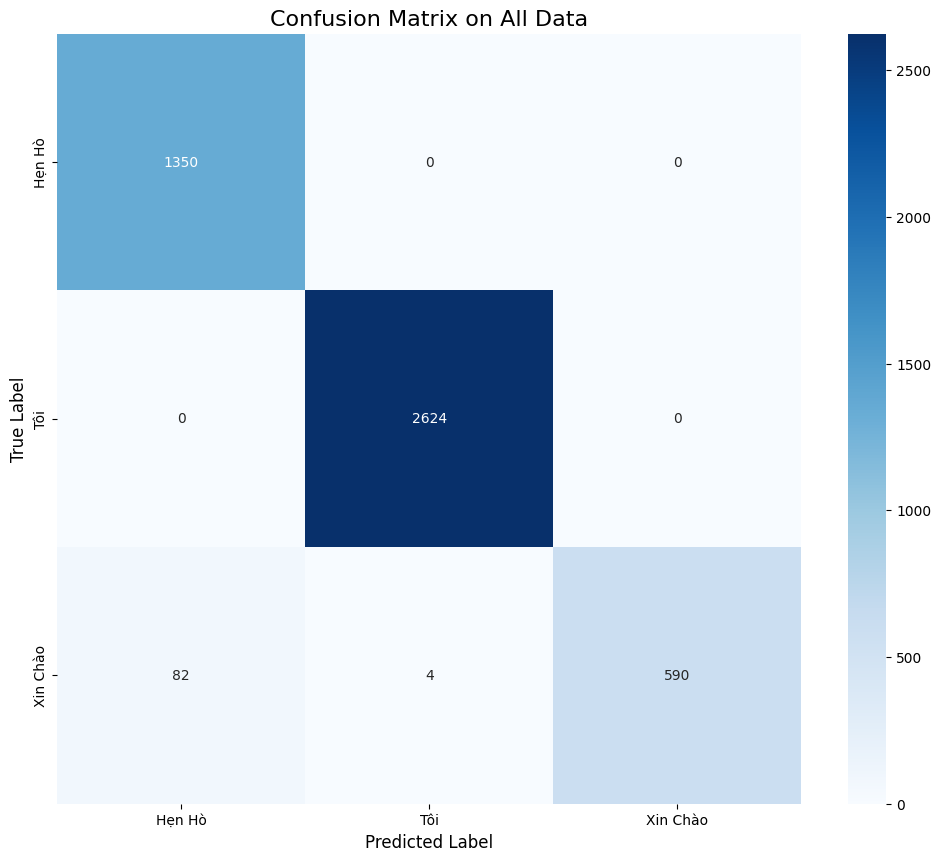

In [12]:
from sklearn.utils.multiclass import unique_labels
print("\n\n--- Training Final Model on All Data for Detailed Analysis ---")

inputs = Input(shape=(TIME_STEPS, X.shape[2]))
x = LSTM(64, return_sequences=True)(inputs)
x = Dropout(0.5)(x)
x = LSTM(64)(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)
final_model = Model(inputs=inputs, outputs=outputs)
final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n--- Starting Final Training ---")
history = final_model.fit(
    X, y,
    epochs=50,
    batch_size=128,
    validation_split=0.2,  # Use 20% of all data for validation monitoring
    callbacks=[EarlyStopping(monitor='val_loss', patience=5)],
    verbose=1
)

# Plot Training History
print("\n\n--- Final Model Training History ---")
plt.figure(figsize=(12, 10))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Final Model Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Final Model Loss')
plt.legend()
plt.show()

# Final Model Performance Analysis
print("\n\n--- Final Model Performance Analysis (on all data) ---")
y_pred_probs = final_model.predict(X)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y, axis=1)

unique_labels_all = np.unique(np.concatenate((y_true, y_pred)))
filtered_class_names = [label_encoder.classes_[i] for i in unique_labels_all]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=unique_labels_all, target_names=filtered_class_names, zero_division=0))

print("\n\nConfusion Matrix:")
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred, labels=unique_labels_all)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=filtered_class_names, yticklabels=filtered_class_names, cmap='Blues')
plt.title('Confusion Matrix on All Data', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

In [13]:
model.save("Training.h5")

/Users/stella/Downloads/Data Training/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [14]:
np.save("label_classes.npy", label_encoder.classes_)
